# PPPA Gazetted Publications — Exploratory Analysis

This notebook explores the dataset of publications gazetted (banned/proscribed) under Malaysia's **Printing Presses and Publications Act (PPPA)**. It is intended as an exploratory tool for researchers reviewing classification quality (Cluster / Subcluster) against metadata such as publication origin, language, and time.

**Sections**
1. Setup & data loading
2. Data cleaning (language list parsing, missing values)
3. Dataset overview
4. Temporal trends
5. Cluster & Subcluster analysis
6. Publication origin & language
7. Publishers & authors
8. Cross-tabulations (cluster × year, origin × cluster)
9. Researcher notes — classification quality flags

## 1. Setup & data loading

In [39]:
import ast
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 80)

VIZ_DIR = "visualizations"
os.makedirs(VIZ_DIR, exist_ok=True)
print(f"Visualizations will be saved to: {os.path.abspath(VIZ_DIR)}")

def save(name):
    """Save the current figure to the visualizations directory."""
    path = os.path.join(VIZ_DIR, f"{name}.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved → {path}")

Visualizations will be saved to: /home/erinmq/Projects/pppa-analysis/visualizations


In [40]:
df = pd.read_csv("sample_data.csv")
df = df.loc[:, ~df.columns.str.startswith("Unnamed")]

print(f"Rows: {len(df):,}  |  Columns: {len(df.columns)}")
df.head()

Rows: 3,187  |  Columns: 13


,Publication Title,Gazette Date,Year,Gazette Number,Publication Type,Author/Translator,Publisher,Publication Origin,Printer,Language,Cluster,Subcluster,Notes
0,"BEATING UP GONGS & DRUMS, AND SING",1951-04-27,1951,L.N. 263.,Printed Documents,NaN,SHANGHAI PUBLISHING CO.,Foreign,NaN,"[""Chinese""]",Subversive ideological and political content,Communism/socialism,NaN
1,NEW YEAR'S DAY,1950-07-29,1950,L.N. 331.,Printed Documents,KAM LO,KAU SAT PUBLISHING CO.,Foreign,NaN,NaN,General/Unindentified,Administrative/Unclear Ground,NaN
2,FOLK SONGS OF THE WORLD,1952-06-12,1952,L.N.329,Printed Documents,YIP LO,"ONWARD BOOKSHOP,HONG KONG",Foreign,NaN,"[""Chinese""]",Subversive ideological and political content,Communism/socialism,NaN
3,MALAYAN MONITOR,1966-09-15,1966,P.U.344,Printed Documents,NaN,H.B.LIM,Foreign,THE CHINESE LANGUAGE,"[""Chinese""]",Subversive ideological and political content,Communism/socialism,"Publication origin is foreign becuase it was published in London, source -> ..."
4,BEFORE ENTERING THE NEW SOCIETY,1951-04-27,1951,L.N. 263.,Printed Documents,HUANG YU,NAN KUO BOOKSHOP,Foreign,NaN,"[""Chinese""]",Subversive ideological and political content,Communism/socialism,NaN


## 2. Data cleaning

A few columns need normalisation before they are safe to group on:

- **`Gazette Date`** — parse to a proper datetime.
- **`Language`** — stored as a stringified JSON list (e.g. `["Chinese"]`). Parse it so we can filter and explode.
- **`Cluster` / `Subcluster`** — a single publication sometimes has multiple subclusters separated by commas.
- **`n/a`** vs real NaN — we keep `"n/a"` where the researcher explicitly recorded it (it is a meaningful signal), but treat empty strings as missing.

In [41]:
df["Gazette Date"] = pd.to_datetime(df["Gazette Date"], errors="coerce")
df["Year"] = pd.to_numeric(df["Year"], errors="coerce").astype("Int64")

def parse_language(raw):
    if pd.isna(raw) or raw == "n/a":
        return []
    try:
        value = ast.literal_eval(raw)
        return value if isinstance(value, list) else [str(value)]
    except (ValueError, SyntaxError):
        return [raw]

df["Languages"] = df["Language"].apply(parse_language)

def split_subclusters(raw):
    if pd.isna(raw):
        return []
    return [s.strip() for s in str(raw).split(",") if s.strip()]

df["Subclusters"] = df["Subcluster"].apply(split_subclusters)

df[["Publication Title", "Gazette Date", "Year", "Languages", "Cluster", "Subclusters"]].head()

,Publication Title,Gazette Date,Year,Languages,Cluster,Subclusters
0,"BEATING UP GONGS & DRUMS, AND SING",1951-04-27,1951,[Chinese],Subversive ideological and political content,[Communism/socialism]
1,NEW YEAR'S DAY,1950-07-29,1950,[],General/Unindentified,[Administrative/Unclear Ground]
2,FOLK SONGS OF THE WORLD,1952-06-12,1952,[Chinese],Subversive ideological and political content,[Communism/socialism]
3,MALAYAN MONITOR,1966-09-15,1966,[Chinese],Subversive ideological and political content,[Communism/socialism]
4,BEFORE ENTERING THE NEW SOCIETY,1951-04-27,1951,[Chinese],Subversive ideological and political content,[Communism/socialism]


In [42]:
missing = df.isna().sum().sort_values(ascending=False)
na_literal = (df == "n/a").sum().sort_values(ascending=False)
summary = pd.DataFrame({"NaN": missing, "Literal 'n/a'": na_literal})
summary["Total blank"] = summary.sum(axis=1)
summary[summary["Total blank"] > 0]

,NaN,Literal 'n/a',Total blank
Author/Translator,1215,0,1215
Language,264,0,264
Notes,3084,0,3084
Printer,2099,0,2099
Publication Title,1,0,1
Publisher,446,0,446


## 3. Dataset overview

In [43]:
print(f"Total publications: {len(df):,}")
print(f"Year range: {df['Year'].min()} – {df['Year'].max()}")
print(f"Distinct clusters: {df['Cluster'].nunique()}")
print(f"Distinct publishers: {df['Publisher'].nunique():,}")
print(f"Distinct gazette entries: {df['Gazette Number'].nunique():,}")

Total publications: 3,187
Year range: 1950 – 2025
Distinct clusters: 6
Distinct publishers: 1,757
Distinct gazette entries: 612


Saved → visualizations/01_type_and_origin_overview.png


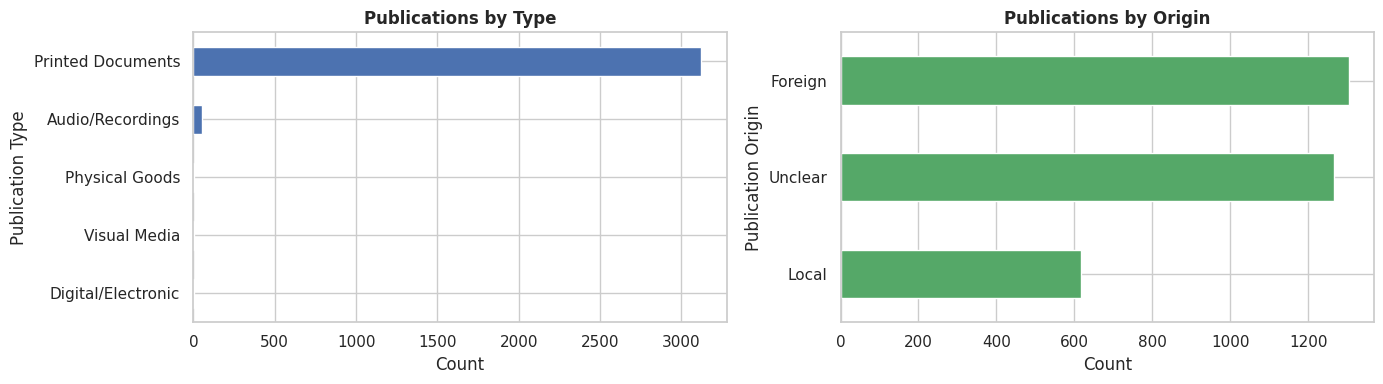

In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df["Publication Type"].value_counts().plot(kind="barh", ax=axes[0], color="#4C72B0")
axes[0].set_title("Publications by Type")
axes[0].set_xlabel("Count")
axes[0].invert_yaxis()

df["Publication Origin"].value_counts().plot(kind="barh", ax=axes[1], color="#55A868")
axes[1].set_title("Publications by Origin")
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
save("01_type_and_origin_overview")
plt.show()

## 4. Temporal trends

How has the volume of gazetted publications changed over time, and do the dominant **clusters** shift between decades?

Saved → visualizations/02_publications_per_year.png


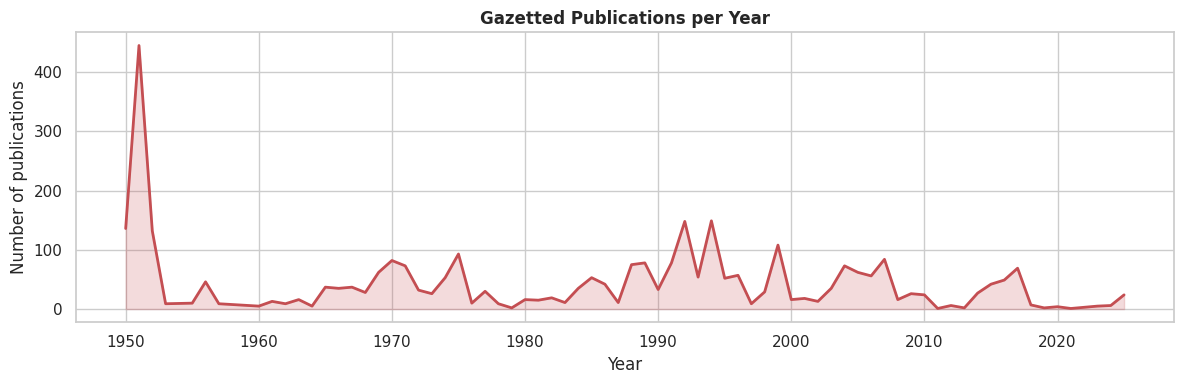

In [45]:
yearly = df.groupby("Year").size()

fig, ax = plt.subplots(figsize=(12, 4))
yearly.plot(ax=ax, color="#C44E52", linewidth=2)
ax.fill_between(yearly.index, yearly.values, alpha=0.2, color="#C44E52")
ax.set_title("Gazetted Publications per Year")
ax.set_xlabel("Year")
ax.set_ylabel("Number of publications")
plt.tight_layout()
save("02_publications_per_year")
plt.show()

Saved → visualizations/03_clusters_by_decade.png


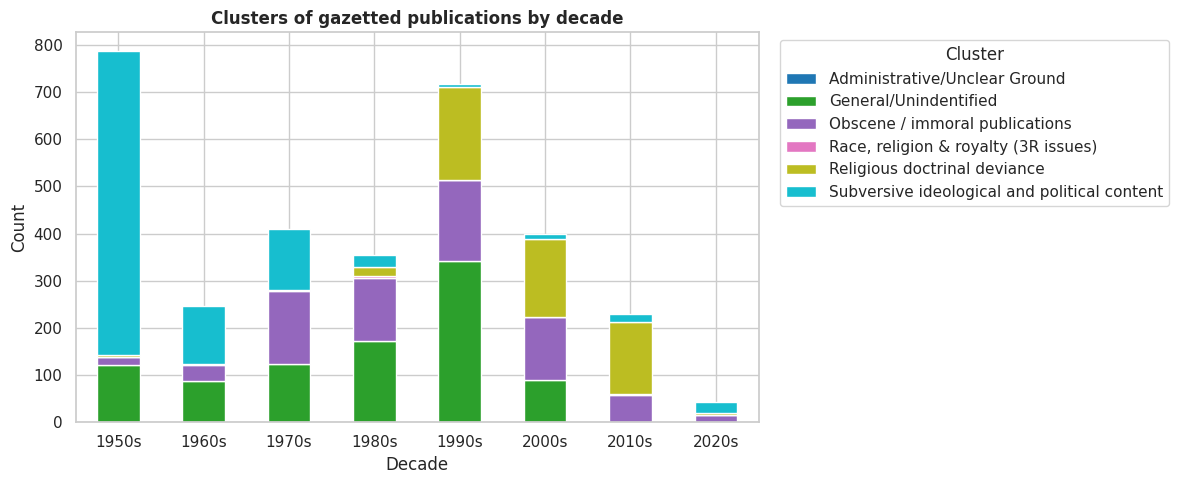

In [46]:
df["Decade"] = (df["Year"] // 10 * 10).astype("Int64").astype("string") + "s"

decade_cluster = (
    df.groupby(["Decade", "Cluster"]).size().unstack(fill_value=0)
      .sort_index()
)

ax = decade_cluster.plot(kind="bar", stacked=True, figsize=(12, 5), colormap="tab10")
ax.set_title("Clusters of gazetted publications by decade")
ax.set_ylabel("Count")
ax.set_xlabel("Decade")
ax.legend(title="Cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
save("03_clusters_by_decade")
plt.show()

## 5. Cluster & Subcluster analysis

Saved → visualizations/04_cluster_counts.png


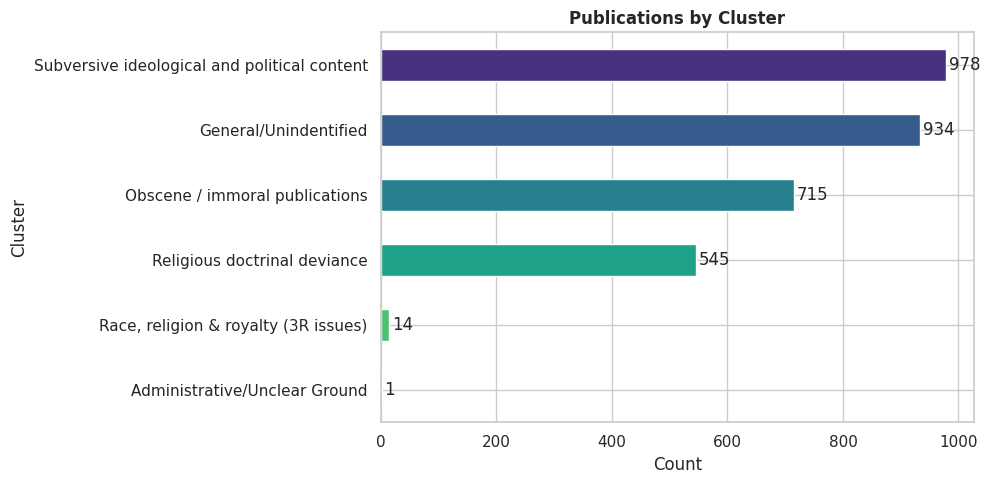

In [47]:
cluster_counts = df["Cluster"].value_counts()

fig, ax = plt.subplots(figsize=(10, 5))
cluster_counts.plot(kind="barh", ax=ax, color=sns.color_palette("viridis", len(cluster_counts)))
ax.set_title("Publications by Cluster")
ax.set_xlabel("Count")
ax.invert_yaxis()
for i, v in enumerate(cluster_counts.values):
    ax.text(v + 5, i, str(v), va="center")
plt.tight_layout()
save("04_cluster_counts")
plt.show()

Saved → visualizations/05_top_subclusters.png


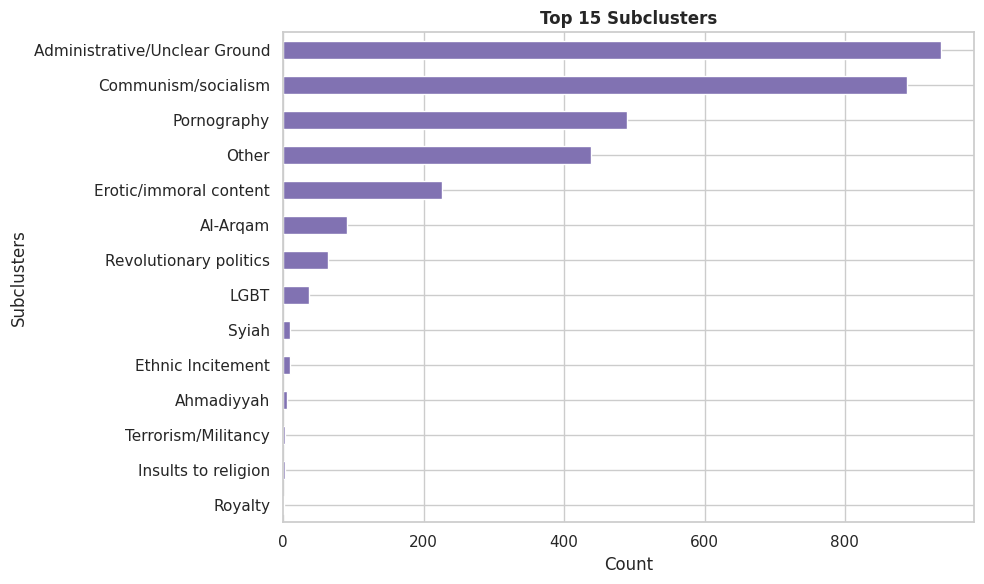

In [48]:
sub = df.explode("Subclusters")
sub = sub[sub["Subclusters"].notna() & (sub["Subclusters"] != "")]

top_sub = sub["Subclusters"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top_sub.plot(kind="barh", ax=ax, color="#8172B2")
ax.set_title("Top 15 Subclusters")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
save("05_top_subclusters")
plt.show()

## 6. Publication origin & language

Saved → visualizations/06_top_languages.png


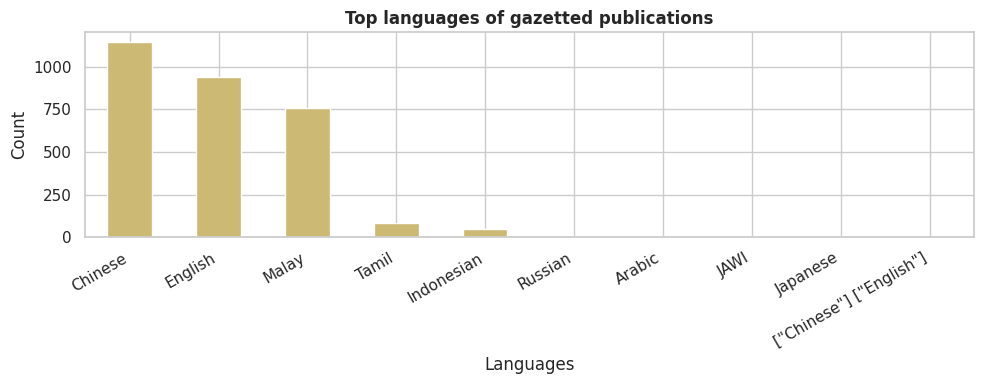

In [49]:
lang = df.explode("Languages")
lang = lang[lang["Languages"].notna() & (lang["Languages"] != "")]

lang_counts = lang["Languages"].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 4))
lang_counts.plot(kind="bar", ax=ax, color="#CCB974")
ax.set_title("Top languages of gazetted publications")
ax.set_ylabel("Count")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
save("06_top_languages")
plt.show()

Saved → visualizations/07_origin_x_language.png


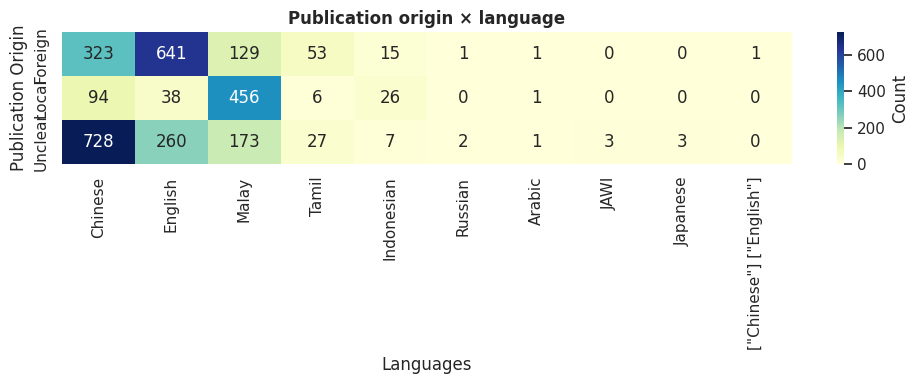

In [50]:
origin_lang = (
    lang.groupby(["Publication Origin", "Languages"]).size()
        .unstack(fill_value=0)
)
top_langs = lang_counts.index.tolist()
origin_lang = origin_lang[top_langs]

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(origin_lang, annot=True, fmt="d", cmap="YlGnBu", ax=ax, cbar_kws={"label": "Count"})
ax.set_title("Publication origin × language")
plt.tight_layout()
save("07_origin_x_language")
plt.show()

## 7. Publishers & authors

Saved → visualizations/08_top_publishers.png


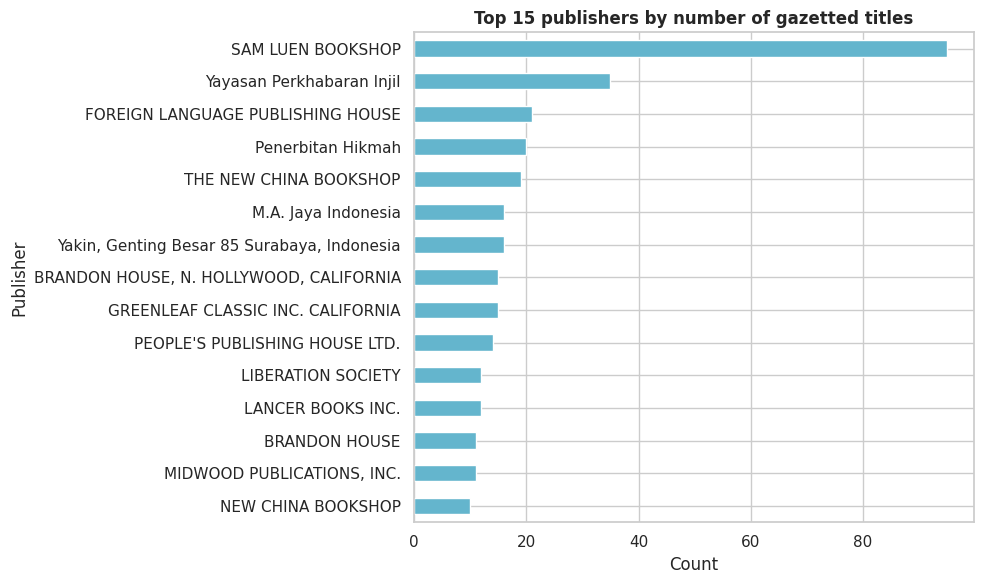

In [51]:
top_publishers = (
    df.loc[df["Publisher"].notna() & (df["Publisher"] != "n/a"), "Publisher"]
      .value_counts()
      .head(15)
)

fig, ax = plt.subplots(figsize=(10, 6))
top_publishers.plot(kind="barh", ax=ax, color="#64B5CD")
ax.set_title("Top 15 publishers by number of gazetted titles")
ax.set_xlabel("Count")
ax.invert_yaxis()
plt.tight_layout()
save("08_top_publishers")
plt.show()

In [52]:
author_known = df["Author/Translator"].where(
    df["Author/Translator"].notna() & (df["Author/Translator"] != "n/a")
)
known_rate = author_known.notna().mean()
print(f"Author/Translator recorded for {known_rate:.1%} of publications")

Author/Translator recorded for 61.9% of publications


## 8. Cross-tabulations

Heatmaps let the researcher spot whether specific clusters concentrate disproportionately in particular origins or time periods.

Saved → visualizations/09_origin_x_cluster.png


/tmp/ipykernel_38133/626733093.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


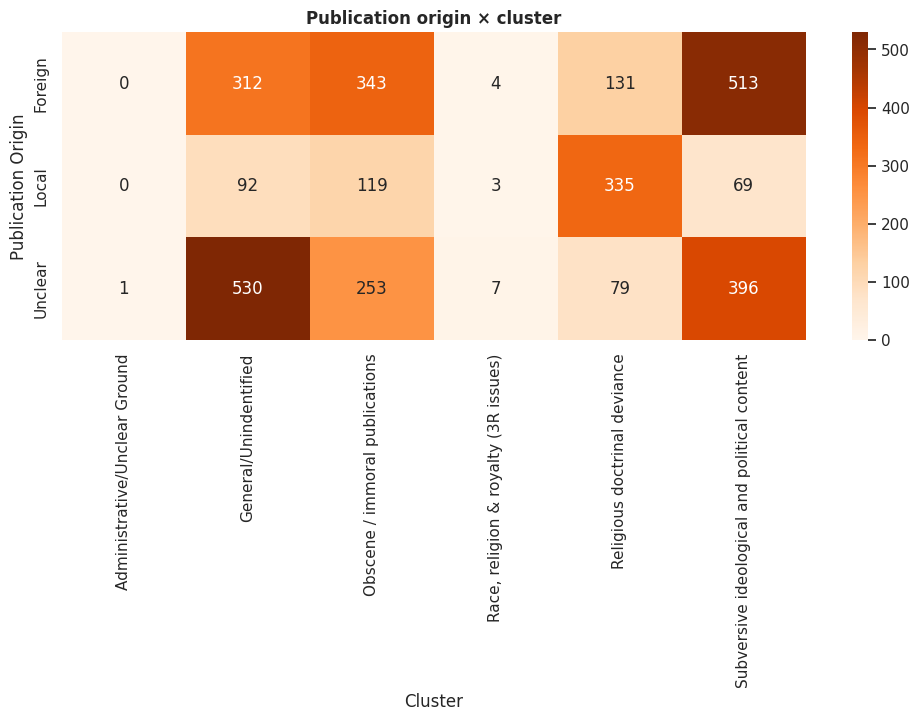

In [53]:
origin_cluster = (
    df.groupby(["Publication Origin", "Cluster"]).size().unstack(fill_value=0)
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(origin_cluster, annot=True, fmt="d", cmap="Oranges", ax=ax)
ax.set_title("Publication origin × cluster")
plt.tight_layout()
save("09_origin_x_cluster")
plt.show()

Saved → visualizations/10_cluster_mix_by_decade.png


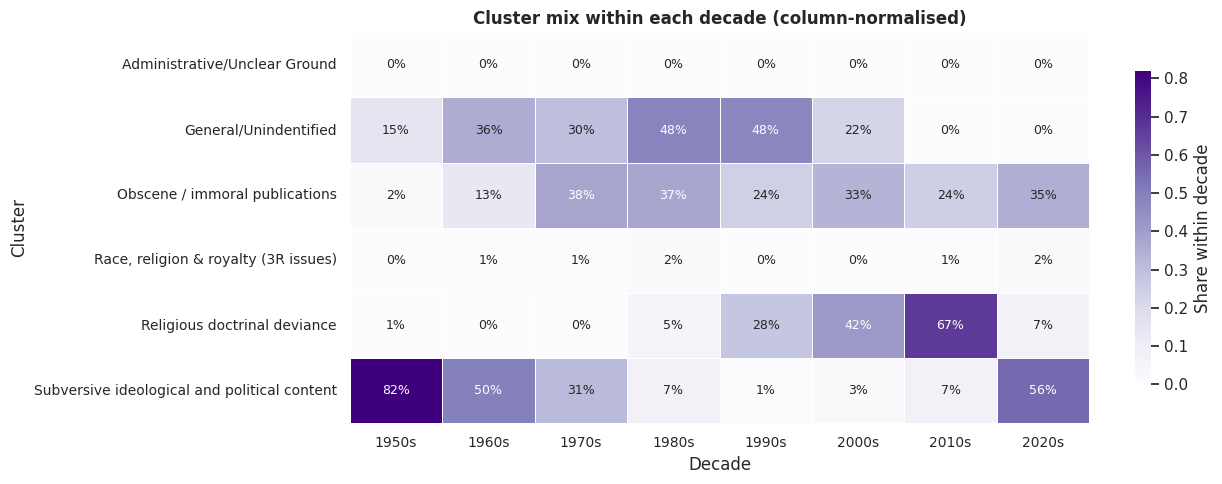

In [54]:
decade_cluster_norm = decade_cluster.div(decade_cluster.sum(axis=1), axis=0).fillna(0)

# Transpose: clusters as rows (y-axis), decades as columns — avoids long label overlap
data = decade_cluster_norm.T

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    data,
    annot=True,
    fmt=".0%",
    cmap="Purples",
    ax=ax,
    linewidths=0.4,
    annot_kws={"size": 9},
    cbar_kws={"label": "Share within decade", "shrink": 0.8},
)
ax.set_title("Cluster mix within each decade (column-normalised)")
ax.set_xlabel("Decade")
ax.set_ylabel("Cluster")
ax.tick_params(axis="y", labelsize=10, rotation=0)
ax.tick_params(axis="x", labelsize=10)
plt.tight_layout()
save("10_cluster_mix_by_decade")
plt.show()

## 9. Researcher notes — classification quality flags

The `Notes` column frequently captures the researcher's judgement about how well the LLM / keyword assignment agrees with the ground truth. The two charts below separate the coverage (how many records have any note) from the breakdown of note types.

In [55]:
def categorise_note(note):
    if pd.isna(note) or not str(note).strip():
        return "No note"
    n = str(note).lower()
    has_llm = "llm" in n
    has_kw = "keyword" in n
    wrong = "wrong" in n or "don't" in n or "dont" in n or "no match" in n
    correct = "correct" in n
    if has_llm and has_kw and wrong and correct:
        return "LLM wrong / Keywords correct"
    if has_llm and has_kw and wrong:
        return "Both LLM & Keywords wrong"
    if "further confirmation" in n or "needs more information" in n:
        return "Needs more info / confirmation"
    if "cannot find" in n or "cannot determine" in n:
        return "Insufficient info"
    return "Other note"

df["Note Category"] = df["Notes"].apply(categorise_note)
note_counts = df["Note Category"].value_counts()

flagged = note_counts.drop("No note", errors="ignore")
pct_flagged = flagged.sum() / len(df) * 100
print(f"Records with a researcher note: {flagged.sum():,} ({pct_flagged:.1f}% of total)")

Records with a researcher note: 103 (3.2% of total)


Saved → visualizations/11_researcher_note_flags.png


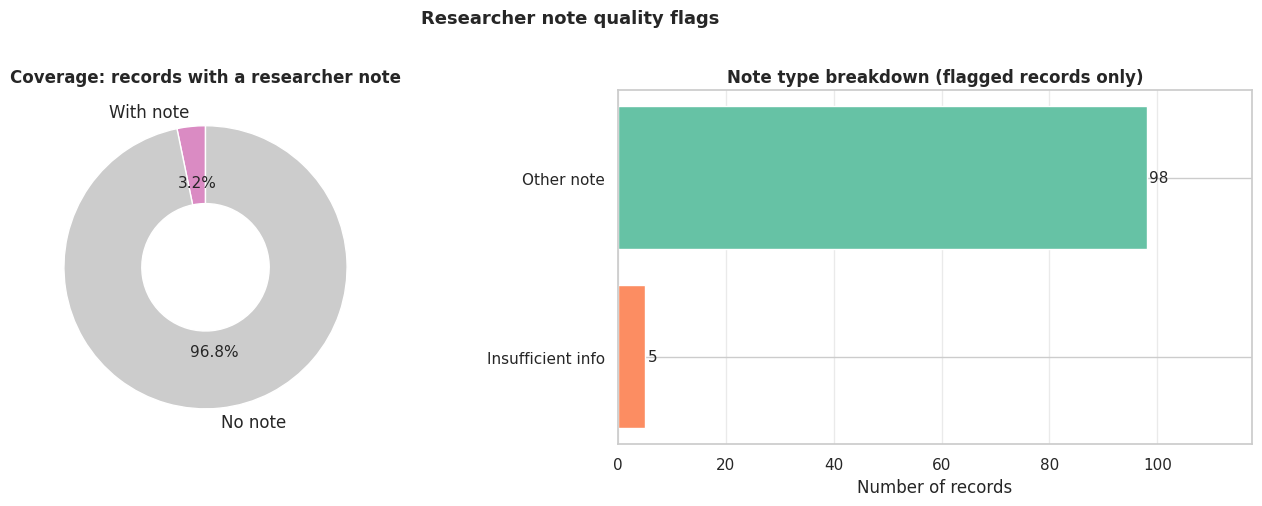

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: noted vs un-noted (donut)
noted_vs_not = pd.Series(
    {"With note": flagged.sum(), "No note": note_counts.get("No note", 0)}
)
wedges, texts, autotexts = axes[0].pie(
    noted_vs_not,
    labels=noted_vs_not.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=["#DA8BC3", "#CCCCCC"],
    wedgeprops={"width": 0.55},
    textprops={"fontsize": 12},
)
for at in autotexts:
    at.set_fontsize(11)
axes[0].set_title("Coverage: records with a researcher note")

# Right: breakdown of note types (excluding 'No note')
palette = sns.color_palette("Set2", len(flagged))
bars = axes[1].barh(flagged.index[::-1], flagged.values[::-1], color=palette[::-1])
axes[1].set_title("Note type breakdown (flagged records only)")
axes[1].set_xlabel("Number of records")
axes[1].tick_params(axis="y", labelsize=11)
for bar, v in zip(bars, flagged.values[::-1]):
    axes[1].text(v + 0.5, bar.get_y() + bar.get_height() / 2, str(v),
                 va="center", ha="left", fontsize=11)
axes[1].set_xlim(0, flagged.max() * 1.2)
axes[1].grid(axis="x", alpha=0.4)

plt.suptitle("Researcher note quality flags", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
save("11_researcher_note_flags")
plt.show()

In [57]:
# Sample rows for each note category
(
    df[df["Note Category"] != "No note"]
      .groupby("Note Category")
      .apply(lambda g: g[["Publication Title", "Cluster", "Notes"]].head(3))
      .reset_index(drop=True)
)

,Publication Title,Cluster,Notes
0,A COLLECTION OF SONGS(NO.1 SERIES),Subversive ideological and political content,Cannot determine what language were the songs and the sub-cluster.
1,BIOGRAPHY OF WORLD'S GREATEST SOVIET WRITER,Subversive ideological and political content,Cannot find information on publication origin but it was assumed that it is ...
2,SING TOGETHER,Subversive ideological and political content,Cannot find information on the cluster but assumed it is likely as selected ...
3,MALAYAN MONITOR,Subversive ideological and political content,"Publication origin is foreign becuase it was published in London, source -> ..."
4,A COMPILATION OF MATERIALS ON THE VIETNAM ISSUE,Subversive ideological and political content,Green because of cluster and sub-cluster determination
5,BRIEF COURSE OF CHINESE HISTORY,Subversive ideological and political content,Evidence of publication origin being Local is because of Kwong Wah Yit Pau


---

### Next directions for the researcher

- **Disagreement deep-dives** — drill into the *LLM wrong / Keywords correct* bucket: is it concentrated in a specific language or cluster?
- **Publisher networks** — the top publishers likely form clusters by origin and era; a network graph could reveal distribution chains.
- **Title-level text analysis** — TF-IDF or topic modelling on `Publication Title` could surface themes that the cluster labels miss.
- **Temporal gaps** — years with unusually low counts may reflect missing gazette data rather than a genuine drop; cross-check against external gazette archives.